# Representation Learning and Sequence Modeling in High-Dimensional Data


In [8]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

DATA_PATH = Path("/home/themad/Documents/yeshiva/dataScience/assignments/GDP/data.csv")


## Data Generating Process (DGP) Hypothesis

In this case study, each customer's behavior is observed only through **transactional line items** (invoices, items, quantities, prices, timestamps). I treat future purchase-related outcomes as generated by an underlying process that depends on **how recently and how often** the customer shops, **how much they spend**, **how concentrated or diverse** their basket is, and **temporal patterns**, plus unobserved shocks:

`future_behavior ≈ g(recency, frequency, spend_level, basket_diversity, temporal_patterns, context) + ε`

Intuitively (mapped to engineered customer-level features):

- **`n_invoices`** and **`mean_interpurchase_days`** proxy purchase frequency and cadence between orders.
- **`total_spend`** and **`avg_invoice_value`** proxy monetary propensity and typical basket value per invoice.
- **`recency_days`** measures how recently the customer was active relative to the latest transaction date in the dataset.
- **`item_diversity_ratio`** measures whether purchases are spread across many distinct products or concentrated in a few.

The noise term **ε** aggregates factors not fully summarized by these features, such as promotions, stock availability, pricing changes, one-off bulk orders, and idiosyncratic shopping motives.

Important **omitted variables** likely affect behavior but are not explicit columns here (e.g. marketing exposure, competitor prices, demographics, product substitution beyond coarse stock codes).

There is also **coverage and selection bias**: many rows lack `CustomerID`; the modeling stream uses **positive purchase** transactions after cleaning returns/cancellations and invalid economics. Conclusions describe **observed transactional behavior under these constraints**, not universal consumer behavior.

Later sections use EDA, unsupervised structure discovery, and (in subsequent phases) supervised models to probe how well summaries of `g(·)` support prediction and whether richer sequence representations add value.

## 1) Load Raw Data and Validate Canonical Schema

In [9]:
RAW_SCHEMA = {
    "InvoiceNo": "string",
    "StockCode": "string",
    "Description": "string",
    "Quantity": "Int64",
    "InvoiceDate": "string",
    "UnitPrice": "float64",
    "CustomerID": "string",
    "Country": "string",
}

required_columns = list(RAW_SCHEMA.keys())

# Online Retail files are often cp1252/latin1 encoded, not strict utf-8.
try:
    df_raw = pd.read_csv(DATA_PATH, encoding="utf-8")
    used_encoding = "utf-8"
except UnicodeDecodeError:
    df_raw = pd.read_csv(DATA_PATH, encoding="latin1")
    used_encoding = "latin1"

missing_cols = [c for c in required_columns if c not in df_raw.columns]
if missing_cols:
    raise ValueError(f"Dataset is missing required columns: {missing_cols}")

for c, dtype in RAW_SCHEMA.items():
    if c == "InvoiceDate":
        continue
    if c in df_raw.columns:
        try:
            df_raw[c] = df_raw[c].astype(dtype)
        except Exception:
            pass

print("Raw shape:", df_raw.shape)
df_raw.head()

Raw shape: (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


The dataset has 541,909 rows with 8 columns including InvoiceNo, StockCode, Description, Quantity, InvoiceDate, UnitPrice, CustomerID, Country

## 1.5) Column Quality Check


In [10]:
quality = pd.DataFrame({
    "dtype": df_raw.dtypes.astype(str),
    "missing_count": df_raw.isna().sum(),
    "missing_pct": (df_raw.isna().mean() * 100).round(2),
    "n_unique": df_raw.nunique(dropna=True),
})

# Column-specific checks aligned with assignment contract
quality.loc["CustomerID", "blank_like_count"] = int(
    df_raw["CustomerID"].astype("string").str.strip().isin(["", "<NA>", "nan", "None"]).sum()
)
quality.loc["InvoiceDate", "unparseable_count"] = int(
    pd.to_datetime(df_raw["InvoiceDate"], errors="coerce", utc=True).isna().sum()
)
quality.loc["Quantity", "nonpositive_count"] = int((pd.to_numeric(df_raw["Quantity"], errors="coerce") <= 0).sum())
quality.loc["UnitPrice", "nonpositive_count"] = int((pd.to_numeric(df_raw["UnitPrice"], errors="coerce") <= 0).sum())
quality.loc["InvoiceNo", "cancel_prefix_count"] = int(
    df_raw["InvoiceNo"].astype("string").str.startswith("C", na=False).sum()
)

# Whole-row duplicate audit on canonical columns (raw view)
canonical_cols = ["InvoiceNo", "StockCode", "Description", "Quantity", "InvoiceDate", "UnitPrice", "CustomerID", "Country"]
raw_dupes = int(df_raw.duplicated(subset=canonical_cols).sum())

print(f"Raw exact duplicates on canonical columns: {raw_dupes:,}")

quality_display = quality.copy()
quality_display = quality_display.fillna("-")
quality_display


Raw exact duplicates on canonical columns: 5,268


,dtype,missing_count,missing_pct,n_unique,blank_like_count,unparseable_count,nonpositive_count,cancel_prefix_count
InvoiceNo,string,0,0.00,25900,-,-,-,9288.0
StockCode,string,0,0.00,4070,-,-,-,-
Description,string,1454,0.27,4223,-,-,-,-
Quantity,Int64,0,0.00,722,-,-,10624.0,-
InvoiceDate,str,0,0.00,23260,-,0.0,-,-
UnitPrice,float64,0,0.00,1630,-,-,2517.0,-
CustomerID,string,135080,24.93,4372,0.0,-,-,-
Country,string,0,0.00,38,-,-,-,-


Quality checks on 541,909 records identified 5,268 exact duplicate transaction rows and substantial identifier missingness (24.93% missing CustomerID, 135,080 rows), which materially affects customer-level sequence construction. Timestamp integrity was high (0 unparseable InvoiceDate values). Return/cancellation behavior was non-trivial (9,288 cancellation-marked invoices; 10,624 non-positive quantities), and 2,517 rows had non-positive prices. Accordingly, we deduplicated records and restricted the purchase modeling stream to customer-identified, positive-quantity, positive-price, non-cancellation transactions, while retaining auditable flags in the cleaned table.”

## 2) Cleaning Contract Implementation

Policies implemented:
- Drop rows with missing `CustomerID` and convert to Integer
- Normalize `StockCode, InvoiceNo, Country, Description`
- Remove exact duplicates
- Tag cancellations and returns

Pipeline roadmap used throughout the notebook:
- `df_raw` -> original loaded dataset
- `transactions_clean` -> cleaned transactions with audit flags
- `transactions_purchase` -> purchase-only transaction stream for behavior modeling
- `customer_events` -> feature-engineered event table derived from `transactions_purchase`
- `customer_features_base` -> customer-level aggregated table (one row per customer)


In [11]:
df = df_raw.copy()

# Normalize fields
for col in ["InvoiceNo", "StockCode", "Country", "Description"]:
    df[col] = df[col].astype("string").str.strip()

# Normalize CustomerID to nullable integer IDs.
df["CustomerID"] = pd.to_numeric(df["CustomerID"], errors="coerce").astype("Int64")

# Parse timestamps (no date-row cleaning applied)
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"], errors="coerce", utc=True).dt.tz_localize(None)

# Tag cancellation/return behavior
df["is_cancel_invoice"] = df["InvoiceNo"].str.startswith("C", na=False)
df["is_return_qty"] = df["Quantity"].fillna(0) <= 0
df["is_nonpositive_price"] = df["UnitPrice"].fillna(0) <= 0

# Retention checkpoints
retention = []
def checkpoint(name, frame):
    retention.append({
        "step": name,
        "rows": int(len(frame)),
        "unique_customers": int(frame["CustomerID"].nunique(dropna=True)),
    })

checkpoint("raw", df)

# Drop missing CustomerID
df = df[df["CustomerID"].notna()].copy()
checkpoint("after_customerid_filter", df)

# Remove exact duplicates on canonical fields
canonical_cols = [
    "InvoiceNo", "StockCode", "Description", "Quantity", "InvoiceDate", "UnitPrice", "CustomerID", "Country"
]
df = df.drop_duplicates(subset=canonical_cols).copy()
checkpoint("after_dedup", df)

# transactions_clean (auditable cleaned lines)
transactions_clean = df.copy()
transactions_clean["LineAmount"] = transactions_clean["Quantity"].astype(float) * transactions_clean["UnitPrice"].astype(float)

# purchase-only stream for baseline behavior modeling
transactions_purchase = transactions_clean[
    (~transactions_clean["is_cancel_invoice"])
    & (transactions_clean["Quantity"] > 0)
    & (transactions_clean["UnitPrice"] > 0)
].copy()
checkpoint("purchase_stream", transactions_purchase)

retention_df = pd.DataFrame(retention)
print(retention_df)
print('')
print("transactions_clean shape:", transactions_clean.shape)
print("transactions_purchase shape:", transactions_purchase.shape)

                      step    rows  unique_customers
0                      raw  541909              4372
1  after_customerid_filter  406829              4372
2              after_dedup  401604              4372
3          purchase_stream  392692              4338

transactions_clean shape: (401604, 12)
transactions_purchase shape: (392692, 12)


The dataset initially contained 541,909 transactions across 4,372 unique customers (non-null CustomerID). I first removed rows with missing CustomerID (135,080 rows), reducing the dataset to 406,829 transactions while keeping 4,372 identifiable customers. Next, I removed 5,225 exact duplicate rows (across canonical transaction fields) to reduce double-entry noise. I then restricted the modeling stream to valid positive purchases (Quantity > 0, UnitPrice > 0, and non-cancellation invoices), resulting in 392,692 transactions. I kept two datasets for analysis: transactions_clean (auditable cleaned data including return/cancellation flags) and transactions_purchase (purchase-only stream for behavior modeling).

## Feature Engineering



In [40]:
# One-track feature table for EDA/modeling
customer_events = transactions_purchase[[
    "CustomerID", "InvoiceDate", "InvoiceNo", "StockCode", "Quantity", "UnitPrice", "LineAmount", "Country"
]].copy()

# Add row-level engineered columns directly on transactions_purchase track
customer_events["invoice_day"] = customer_events["InvoiceDate"].dt.floor("D")
customer_events["hour"] = customer_events["InvoiceDate"].dt.hour
customer_events["weekday"] = customer_events["InvoiceDate"].dt.dayofweek
customer_events["month"] = customer_events["InvoiceDate"].dt.to_period("M").dt.to_timestamp()

invoice_level = (
    customer_events.groupby(["CustomerID", "InvoiceNo", "invoice_day"], as_index=False)
    .agg(invoice_value=("LineAmount", "sum"))
    .sort_values(["CustomerID", "invoice_day", "InvoiceNo"])
)

invoice_level["prev_day"] = invoice_level.groupby("CustomerID")["invoice_day"].shift(1)
invoice_level["interpurchase_days"] = (invoice_level["invoice_day"] - invoice_level["prev_day"]).dt.days

invoice_stats = invoice_level.groupby("CustomerID", as_index=False).agg(
    n_invoices=("InvoiceNo", "nunique"),
    avg_invoice_value=("invoice_value", "mean"),
    mean_interpurchase_days=("interpurchase_days", "mean"),
)

# Customer-level aggregates
customer_base = customer_events.groupby("CustomerID", as_index=False).agg(
    n_line_items=("StockCode", "count"),
    n_unique_items=("StockCode", "nunique"),
    total_spend=("LineAmount", "sum"),
    first_purchase=("InvoiceDate", "min"),
    last_purchase=("InvoiceDate", "max"),
)

customer_features_base = customer_base.merge(invoice_stats, on="CustomerID", how="left")

max_date = customer_events["InvoiceDate"].max()
customer_features_base["recency_days"] = (max_date - customer_features_base["last_purchase"]).dt.days
customer_features_base["item_diversity_ratio"] = (
    customer_features_base["n_unique_items"] / customer_features_base["avg_invoice_value"].clip(lower=1)
)

# Merge core customer features back to the one-track table
feature_cols = [
    "CustomerID",
    "n_invoices",
    "total_spend",
    "avg_invoice_value",
    "recency_days",
    "mean_interpurchase_days",
    "item_diversity_ratio",
]

customer_events = customer_events.merge(
    customer_features_base[feature_cols],
    on="CustomerID",
    how="left",
)

# Keep baseline customer table for representation modeling
customer_features_base = customer_features_base[feature_cols].copy()
customer_features_base = customer_features_base.fillna("-")

customer_features_base.head()

,CustomerID,n_invoices,total_spend,avg_invoice_value,recency_days,mean_interpurchase_days,item_diversity_ratio
0,12346,1,77183.60,77183.600000,325,-,0.000013
1,12347,7,4310.00,615.714286,1,60.833333,0.167285
2,12348,4,1797.24,449.310000,74,94.333333,0.048964
3,12349,1,1757.55,1757.550000,18,-,0.041535
4,12350,1,334.40,334.400000,309,-,0.050837


The customer-level feature engineering:

- `n_invoices`: number of invoices per customer.
- `total_spend`: total monetary value spent by the customer across purchases.
- `avg_invoice_value`: average invoice amount for the customer.
- `recency_days`: number of days between the dataset's latest invoice date and the customer's last purchase date.
- `mean_interpurchase_days`: average number of days between consecutive purchases (NaN for one-time buyers).
- `item_diversity_ratio`: unique items purchased divided by total line items purchased by the customer, the higher the ration the more unique items the customer bought

The results show distinct customer behaviors. Customer 12346 spent 77,183.60 on just 1 invoice, with the last purchase occurring about 325 days before the dataset’s latest date, indicating high monetary value but very low purchase frequency. Customer 12347 spent 4,310.00 across 7 invoices, with a recency of 1 day, indicating frequent and recent engagement. The diversity ratio for customer 12347 is o.167 which is higher than for customer 12346, suggesting repeated purchases of some items rather than entirely unique products each time. Overall, customer 12346 appears to be a one-time high-value buyer, while customer 12347 reflects a more consistent repeat-purchase profile.

## 4) Exploratory Data Analysis (EDA)


# Summary Statistics


,count,mean,std,min,25%,50%,75%,max
CustomerID,392692.0,15287.843865,1713.539549,12346.0,13955.0,15150.0,16791.0,18287.0
Quantity,392692.0,13.119702,180.492832,1.0,2.0,6.0,12.0,80995.0
UnitPrice,392692.0,3.125914,22.241836,0.001,1.25,1.95,3.75,8142.75
LineAmount,392692.0,22.6315,311.099224,0.001,4.95,12.45,19.8,168469.6
hour,392692.0,12.721532,2.276661,6.0,11.0,13.0,14.0,20.0
weekday,392692.0,2.606911,1.923929,0.0,1.0,2.0,4.0,6.0
n_invoices,392692.0,18.786285,37.293191,1.0,3.0,7.0,15.0,209.0
total_spend,392692.0,11565.753316,31431.816122,3.75,1097.62,2662.06,6287.77,280206.02
avg_invoice_value,392692.0,554.251731,750.045609,3.45,234.85,360.366154,572.762857,84236.25
recency_days,392692.0,40.11291,65.402913,0.0,3.0,15.0,42.0,373.0


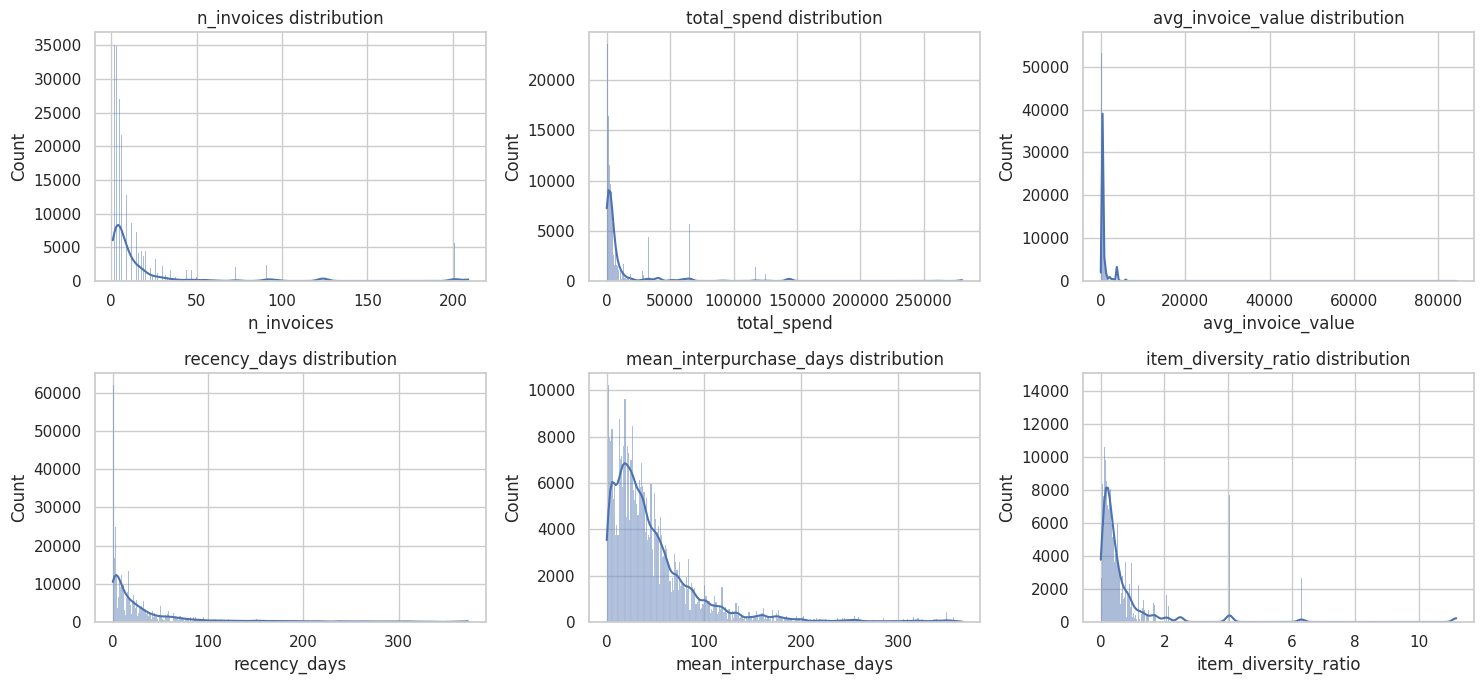

In [61]:
main_df = customer_events.copy()

num_features = [col for col in main_df.columns if pd.api.types.is_numeric_dtype(main_df[col])]
summary = main_df[num_features].describe().T
display(summary)

# Raw-scale marginal distributions for selected engineered features
focus_features = [
    "n_invoices",
    "total_spend",
    "avg_invoice_value",
    "recency_days",
    "mean_interpurchase_days",
    "item_diversity_ratio",
]
plot_features = [c for c in focus_features if c in main_df.columns]

n_cols = 3
n_rows = int(np.ceil(len(plot_features) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 3.5 * n_rows))
axes = np.array(axes).reshape(-1)

for i, col in enumerate(plot_features):
    vals = pd.to_numeric(main_df[col], errors="coerce").dropna()
    sns.histplot(vals, kde=True, ax=axes[i])
    axes[i].set_title(f"{col} distribution")
    axes[i].set_xlabel(col)

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

The purchase stream is highly right-skewed across economic variables. Quantity shows long-tail purchase sizes (median 6 vs extreme maximum 80,995). UnitPrice is similarly skewed (0.001 to 8,142.75 with low central tendency relative to the upper tail). Monetary outcomes (LineAmount/total_spend) are dominated by a small number of high-value observations, indicating strong heterogeneity and outlier sensitivity

# Marginal Distribution

,count,mean,std,min,50%,75%,90%,95%,99%,max
n_invoices,4338.0,4.272015,7.697998,1.000000,2.000000,5.000000,9.000000,13.00000,30.000000,209.000000
total_spend,4338.0,2048.688081,8985.230220,3.750000,668.570000,1660.597500,3640.841000,5789.99950,19780.487800,280206.020000
avg_invoice_value,4338.0,417.645735,1796.511343,3.450000,291.940000,428.280625,659.735167,936.33200,2031.161200,84236.250000
recency_days,4338.0,91.536422,100.014169,0.000000,50.000000,141.000000,262.000000,311.00000,368.000000,373.000000
mean_interpurchase_days,2845.0,72.653930,65.563546,0.000000,53.500000,92.000000,160.000000,210.80000,330.680000,366.000000
item_diversity_ratio,4338.0,0.206352,0.326755,0.000013,0.120136,0.245767,0.457798,0.63932,1.309315,11.179314


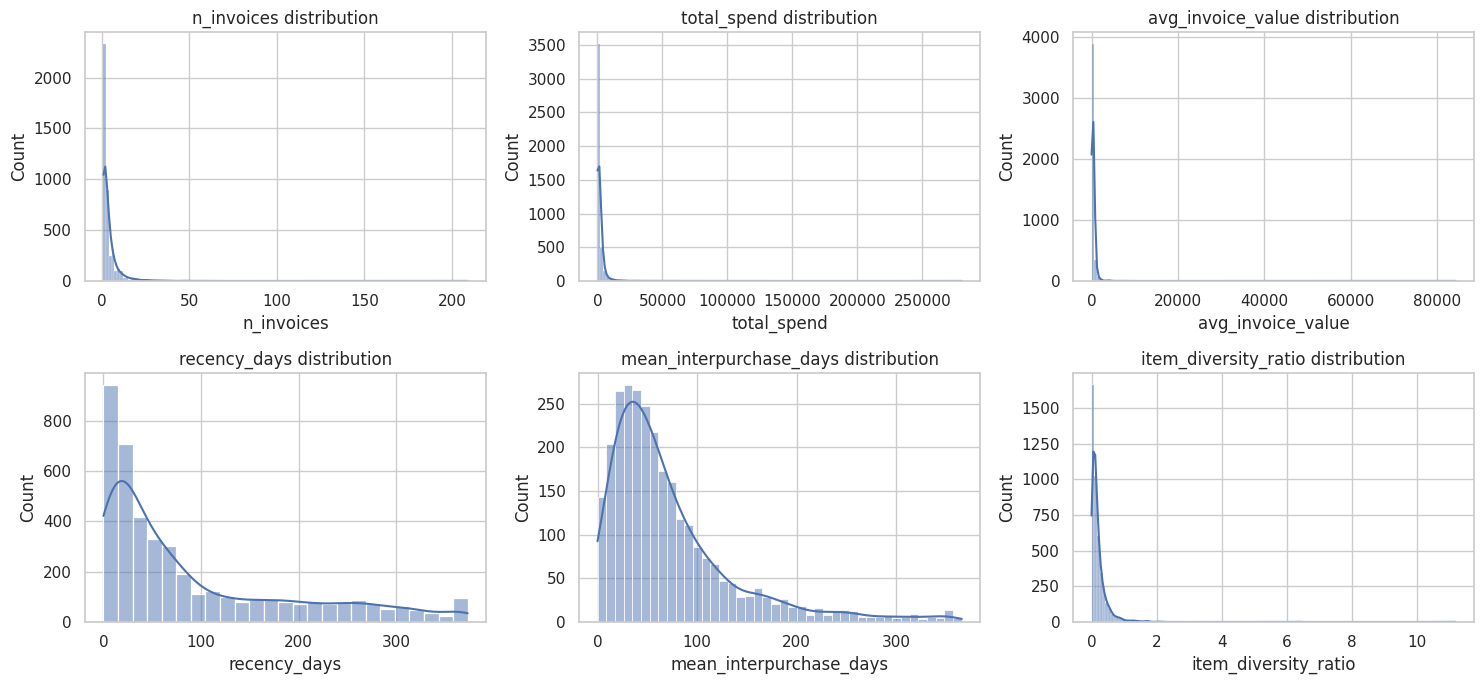

In [62]:
# Marginal distributions for requested engineered features
requested_features = [
    "n_invoices",
    "total_spent",
    "avg_invoice_value",
    "recency_days",
    "mean_interpurchase_days",
    "item_diversity_ratio",
]

plot_df = customer_features_base.copy()

# Handle naming difference: total_spent (requested) vs total_spend (current feature name)
feature_lookup = {"total_spent": "total_spend"}
plot_features = [feature_lookup.get(f, f) for f in requested_features if feature_lookup.get(f, f) in plot_df.columns]

# Summary table for the selected features
summary_table = (
    plot_df[plot_features]
    .apply(pd.to_numeric, errors="coerce")
    .describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99])
    .T
)
display(summary_table)

n_cols = 3
n_rows = int(np.ceil(len(plot_features) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 3.5 * n_rows))
axes = np.array(axes).reshape(-1)

for i, col in enumerate(plot_features):
    vals = pd.to_numeric(plot_df[col], errors="coerce").dropna()
    sns.histplot(vals, kde=True, ax=axes[i])
    axes[i].set_title(f"{col} distribution")
    axes[i].set_xlabel(col)

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

Customer activity is sparse for most users as shown by n_invoices median is 2, while the mean is 4.27 and max is 209, showing a long right tail (few very frequent buyers).
Spending is highly concentrated with total_spend median is 669, but p99 is 19,780 and max is 280,206 so a small minority drives a disproportionate share of revenue.
Average invoice value is also heavy-tailed with median 292 and max 84,236. This suggests occasional very large orders that inflate means.
Recency is broad and heterogeneous with median 50 days, p75 141, p99 368. The base contains both recently active and long-dormant customers.
Purchase cadence varies substantially mean_interpurchase_days median 53.5, p95 210.8, max 366. There are both frequent-repeat and slow-cycle customers.
Product variety is mostly low/moderate as item_diversity_ratio median 0.12, with a long tail up to 11.18, indicating most customers buy relatively concentrated sets of items, while a few are highly varied.

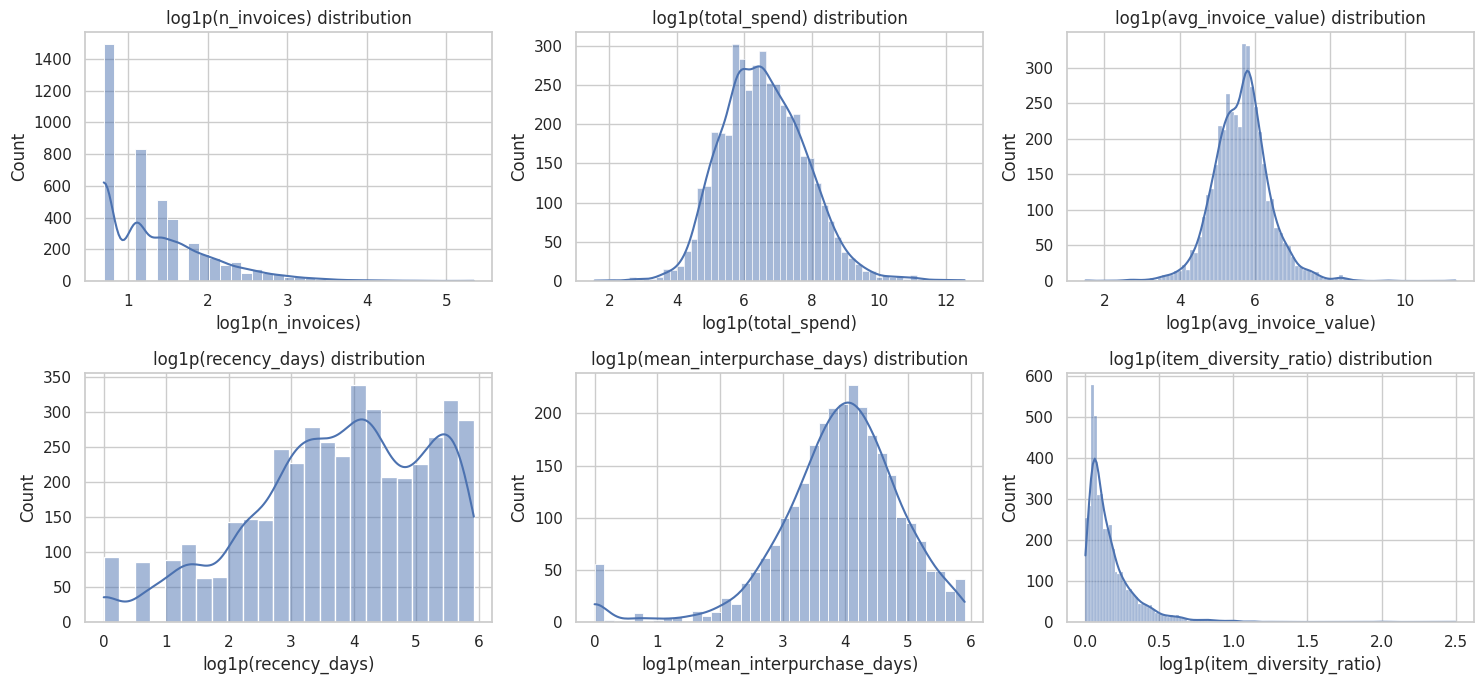

In [ ]:
# Log-transformed marginal distributions (log1p)
log_features = [
    "n_invoices",
    "total_spend",
    "avg_invoice_value",
    "recency_days",
    "mean_interpurchase_days",
    "item_diversity_ratio",
]

plot_df = customer_features_base.copy()

n_cols = 3
n_rows = int(np.ceil(len(log_features) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 3.5 * n_rows))
axes = np.array(axes).reshape(-1)

for i, col in enumerate(log_features):
    vals = pd.to_numeric(plot_df[col], errors="coerce").dropna()
    vals = vals[vals >= 0]  # log1p requires non-negative values
    sns.histplot(np.log1p(vals), kde=True, ax=axes[i])
    axes[i].set_title(f"log1p({col}) distribution")
    axes[i].set_xlabel(f"log1p({col})")

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

Applying log1p transformation compresses the extreme right tails in the customer-level features while preserving rank order and relative differences among customers. After transformation, total_spend, avg_invoice_value, and mean_interpurchase_days become much more symmetric and concentrated around their central ranges, making underlying structure easier to visualize. n_invoices remains discrete and right-skewed, but the dominance of high-frequency outliers is reduced. item_diversity_ratio is still right-skewed, though its tail is materially compressed. recency_days appears broader and mildly multimodal, suggesting multiple behavioral groups (recently active vs dormant customers) rather than a single homogeneous population.

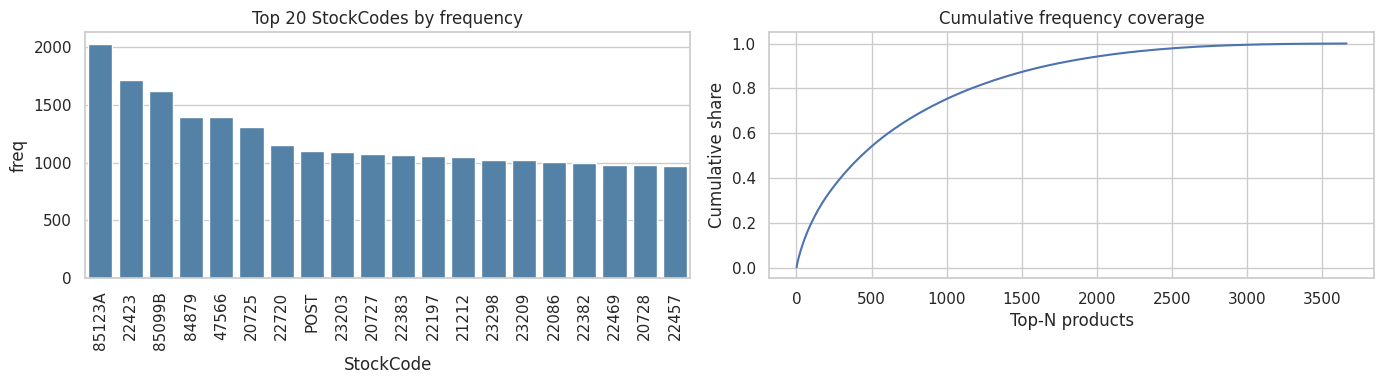

Top  10 items cover 3.53% of line items
Top  20 items cover 6.11% of line items
Top  50 items cover 12.36% of line items
Top 100 items cover 20.33% of line items
Top 500 items cover 54.21% of line items


In [ ]:
# Product Performance and Basket Composition
product_counts = (
    customer_events.groupby("StockCode", as_index=False)
    .agg(freq=("InvoiceNo", "count"))
    .sort_values("freq", ascending=False)
    .reset_index(drop=True)
)

product_counts["cum_share"] = product_counts["freq"].cumsum() / product_counts["freq"].sum()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.barplot(data=product_counts.head(20), x="StockCode", y="freq", ax=axes[0], color="steelblue")
axes[0].set_title("Top 20 StockCodes by frequency")
axes[0].tick_params(axis="x", rotation=90)

axes[1].plot(np.arange(1, len(product_counts)+1), product_counts["cum_share"].values)
axes[1].set_title("Cumulative frequency coverage")
axes[1].set_xlabel("Top-N products")
axes[1].set_ylabel("Cumulative share")

plt.tight_layout()
plt.show()

for n in [10, 20, 50, 100, 500]:
    if n <= len(product_counts):
        share = product_counts.loc[n-1, "cum_share"]
        print(f"Top {n:>3} items cover {share:.2%} of line items")


### EDA 5 interpretation

- Country contribution is uneven, with a few markets driving most transactions and spend.
- Differences between customer share and spend share reveal markets with higher/lower spend intensity per customer.
- Country-level effects should be preserved as features or grouping controls in evaluation.


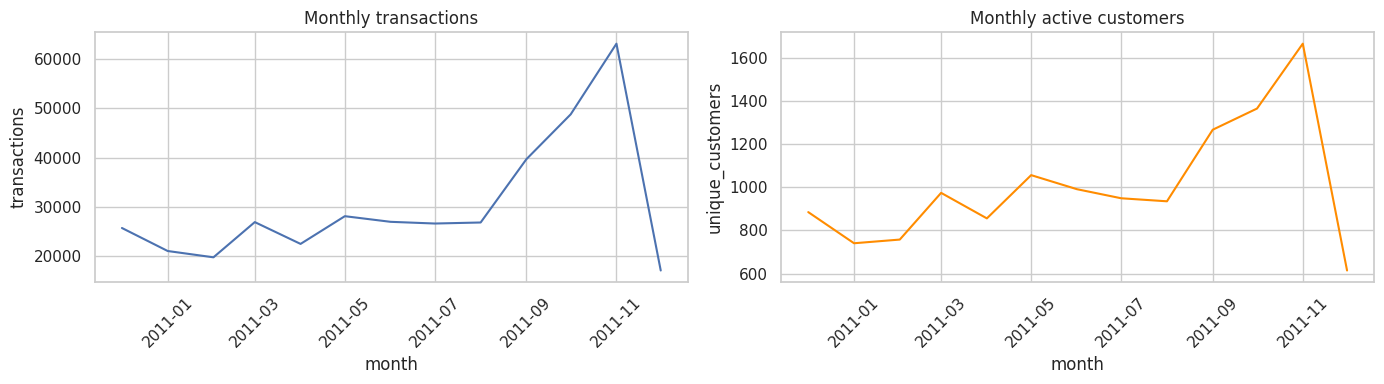

,month,transactions,unique_customers,total_spend
8,2011-08-01,26790,935,644051.040
9,2011-09-01,39669,1266,950690.202
10,2011-10-01,48793,1364,1035642.450
11,2011-11-01,63168,1664,1156205.610
12,2011-12-01,17026,615,517190.440


In [20]:
# EDA 6: Temporal Trends (Hourly, Weekly, Monthly Seasonality)
"""Question: How do transactions and active customers evolve over calendar time?"""
monthly = (
    customer_events.assign(month=customer_events["InvoiceDate"].dt.to_period("M").dt.to_timestamp())
    .groupby("month", as_index=False)
    .agg(
        transactions=("InvoiceNo", "count"),
        unique_customers=("CustomerID", "nunique"),
        total_spend=("LineAmount", "sum"),
    )
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.lineplot(data=monthly, x="month", y="transactions", ax=axes[0])
axes[0].set_title("Monthly transactions")
axes[0].tick_params(axis="x", rotation=45)

sns.lineplot(data=monthly, x="month", y="unique_customers", ax=axes[1], color="darkorange")
axes[1].set_title("Monthly active customers")
axes[1].tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

monthly.tail()

### EDA 6 interpretation

- Activity changes over months in both transaction volume and active-customer count.
- Periods where volume and customer count diverge indicate shifts in basket size/intensity, not just audience size.
- Time-aware validation and temporal features are justified for downstream modeling.


### EDA 7: Returns/Cancellations Impact Analysis

- Quantify cancellation share of transactions and revenue impact.
- Identify products/customers with highest return exposure.
- Compare return behavior over time and by country.


In [22]:
# EDA 7: Returns/Cancellations Impact Analysis
"""Question: How large is cancellation exposure, and where is it concentrated?"""

returns_view = transactions_clean.copy()
returns_view["is_return_line"] = returns_view["Quantity"] < 0

returns_kpi = pd.DataFrame({
    "metric": [
        "cancel_invoice_rate",
        "return_line_rate",
        "gross_sales",
        "net_sales",
        "negative_line_amount",
    ],
    "value": [
        returns_view["is_cancel_invoice"].mean(),
        returns_view["is_return_line"].mean(),
        round(returns_view.loc[returns_view["LineAmount"] > 0, "LineAmount"].sum(), 2),
        round(returns_view["LineAmount"].sum(), 2),
        round(returns_view.loc[returns_view["LineAmount"] < 0, "LineAmount"].sum(), 2),
    ],
})
display(returns_kpi)

returns_by_country = (
    returns_view.groupby("Country", as_index=False)
    .agg(
        lines=("InvoiceNo", "count"),
        cancel_rate=("is_cancel_invoice", "mean"),
        return_rate=("is_return_line", "mean"),
        net_sales=("LineAmount", "sum"),
    )
    .sort_values("net_sales", ascending=False)
)
returns_by_country.head(15)


,metric,value
0,cancel_invoice_rate,2.209141e-02
1,return_line_rate,2.209141e-02
2,gross_sales,8.887209e+06
3,net_sales,8.278519e+06
4,negative_line_amount,-6.086895e+05


,Country,lines,cancel_rate,return_rate,net_sales
35,United Kingdom,356728,0.021027,0.021027,6747156.154
23,Netherlands,2371,0.003374,0.003374,284661.540
10,EIRE,7475,0.033043,0.033043,250001.780
14,Germany,9480,0.047785,0.047785,221509.470
13,France,8475,0.017463,0.017463,196626.050
0,Australia,1258,0.058824,0.058824,137009.770
32,Switzerland,1877,0.018647,0.018647,55739.400
30,Spain,2528,0.018987,0.018987,54756.030
3,Belgium,2069,0.018366,0.018366,40910.960
31,Sweden,461,0.023861,0.023861,36585.410


### EDA 7 interpretation

- Cancellation/return exposure is measurable and should be tracked explicitly, not absorbed into aggregate sales metrics.
- Gross vs net sales comparison quantifies revenue leakage from negative lines.
- Country-level return/cancel rates highlight where robustness checks or market-specific handling may be needed.


In [24]:
# EDA Summary: Decision template (fill after interpretation)
decision_summary = pd.DataFrame([
    {"finding_id": "F01", "artifact": "retention_df", "observation": "", "decision": "", "impacted_phase": "4/6"},
    {"finding_id": "F02", "artifact": "monthly activity", "observation": "", "decision": "", "impacted_phase": "6"},
    {"finding_id": "F03", "artifact": "customer distributions", "observation": "", "decision": "", "impacted_phase": "4/7"},
    {"finding_id": "F04", "artifact": "interpurchase gaps", "observation": "", "decision": "", "impacted_phase": "4"},
    {"finding_id": "F05", "artifact": "product long-tail", "observation": "", "decision": "", "impacted_phase": "4/9"},
    {"finding_id": "F06", "artifact": "country concentration", "observation": "", "decision": "", "impacted_phase": "4/7"},
])

decision_summary

,finding_id,artifact,observation,decision,impacted_phase
0,F01,retention_df,,,4/6
1,F02,monthly activity,,,6
2,F03,customer distributions,,,4/7
3,F04,interpurchase gaps,,,4
4,F05,product long-tail,,,4/9
5,F06,country concentration,,,4/7


## 5) Phase 4 Representation Design

Create three aligned representation families for downstream experiments:
- `raw` (lean baseline)
- `sequence` (baseline + sequence-stat enrichments)
- `latent` (PCA-based embedding + cluster metadata)

In [29]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [30]:
# ---------- A) Raw baseline representation ----------
raw_cols = [
    "n_invoices",
    "total_spend",
    "avg_invoice_value",
    "recency_days",
    "mean_interpurchase_days",
    "item_diversity_ratio",
]

X_raw = customer_features_base[["CustomerID"] + raw_cols].copy()
for c in raw_cols:
    X_raw[c] = pd.to_numeric(X_raw[c], errors="coerce")
X_raw[raw_cols] = X_raw[raw_cols].fillna(X_raw[raw_cols].median(numeric_only=True))

# ---------- B) Sequence-stat representation ----------
seq_extra = invoice_level.groupby("CustomerID", as_index=False).agg(
    invoice_value_std=("invoice_value", "std"),
    invoice_value_median=("invoice_value", "median"),
    interpurchase_days_std=("interpurchase_days", "std"),
    interpurchase_days_median=("interpurchase_days", "median"),
)

seq_extra["invoice_value_std"] = seq_extra["invoice_value_std"].fillna(0)
seq_extra["interpurchase_days_std"] = seq_extra["interpurchase_days_std"].fillna(0)

# Coefficient of variation proxies (guard against divide-by-zero)
seq_extra = seq_extra.merge(
    invoice_level.groupby("CustomerID", as_index=False).agg(invoice_value_mean=("invoice_value", "mean")),
    on="CustomerID",
    how="left",
)
seq_extra["invoice_value_cv"] = np.where(
    seq_extra["invoice_value_mean"].abs() > 1e-9,
    seq_extra["invoice_value_std"] / seq_extra["invoice_value_mean"].abs(),
    0.0,
)
seq_extra = seq_extra.drop(columns=["invoice_value_mean"])

X_seq = X_raw.merge(seq_extra, on="CustomerID", how="left")
seq_cols = [c for c in X_seq.columns if c != "CustomerID"]
X_seq[seq_cols] = X_seq[seq_cols].apply(pd.to_numeric, errors="coerce")
X_seq[seq_cols] = X_seq[seq_cols].fillna(X_seq[seq_cols].median(numeric_only=True))

# ---------- C) Latent representation (PCA + cluster metadata) ----------
latent_input_cols = [c for c in X_seq.columns if c != "CustomerID"]
latent_input = X_seq[latent_input_cols].copy()

scaler = StandardScaler()
latent_scaled = scaler.fit_transform(latent_input)

# Keep enough components to explain 90% variance.
pca = PCA(n_components=0.90, random_state=RANDOM_STATE)
latent_array = pca.fit_transform(latent_scaled)
pca_cols = [f"pca_{i+1}" for i in range(latent_array.shape[1])]

X_latent = pd.DataFrame(latent_array, columns=pca_cols, index=X_seq.index)
X_latent.insert(0, "CustomerID", X_seq["CustomerID"].values)

# Add lightweight unsupervised segment metadata for later comparison.
kmeans = KMeans(n_clusters=5, n_init=10, random_state=RANDOM_STATE)
cluster_id = kmeans.fit_predict(latent_array)
cluster_dist = kmeans.transform(latent_array).min(axis=1)

X_latent["cluster_id"] = cluster_id
X_latent["cluster_dist"] = cluster_dist

# ---------- Representation registry ----------
representations = {
    "raw": X_raw,
    "sequence": X_seq,
    "latent": X_latent,
}

pca_explained = float(pca.explained_variance_ratio_.sum())
print(f"PCA components: {len(pca_cols)} | explained variance: {pca_explained:.3f}")
print("Representations prepared:", list(representations.keys()))

PCA components: 7 | explained variance: 0.949
Representations prepared: ['raw', 'sequence', 'latent']


In [35]:
# Alignment and health checks
base_customers = set(X_raw["CustomerID"])
for name, df_repr in representations.items():
    assert set(df_repr["CustomerID"]) == base_customers, f"CustomerID mismatch in {name}"

repr_summary = []
for name, df_repr in representations.items():
    feature_cols = [c for c in df_repr.columns if c != "CustomerID"]
    repr_summary.append({
        "representation": name,
        "n_rows": len(df_repr),
        "n_features": len(feature_cols),
        "total_nulls": int(df_repr[feature_cols].isna().sum().sum()),
    })

repr_summary_df = pd.DataFrame(repr_summary)
repr_summary_df

,representation,n_rows,n_features,total_nulls
0,raw,4338,6,0
1,sequence,4338,11,0
2,latent,4338,9,0


In [36]:
# Preview each representation
for name, df_repr in representations.items():
    print(f"\n=== {name.upper()} ===")
    print(df_repr.head(3))


=== RAW ===
  CustomerID  n_invoices  total_spend  avg_invoice_value  recency_days  \
0    12346.0           1     77183.60       77183.600000           325   
1    12347.0           7      4310.00         615.714286             1   
2    12348.0           4      1797.24         449.310000            74   

   mean_interpurchase_days  item_diversity_ratio  
0                53.500000              1.000000  
1                60.833333              0.565934  
2                94.333333              0.709677  

=== SEQUENCE ===
  CustomerID  n_invoices  total_spend  avg_invoice_value  recency_days  \
0    12346.0           1     77183.60       77183.600000           325   
1    12347.0           7      4310.00         615.714286             1   
2    12348.0           4      1797.24         449.310000            74   

   mean_interpurchase_days  item_diversity_ratio  invoice_value_std  \
0                53.500000              1.000000           0.000000   
1                60.833333   

## 6) Phase 5 Unsupervised Analysis

Evaluate whether meaningful customer segments emerge across all Phase 4 representation families (`raw`, `sequence`, `latent`) using a consistent clustering protocol.

### Method
- Clustering algorithm: `KMeans`
- Cluster search grid: `k = 2..8`
- Shared metrics: silhouette, Calinski-Harabasz, Davies-Bouldin, inertia
- Selection rule: maximize silhouette; tie-break by lower Davies-Bouldin

In [ ]:
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

In [37]:
# Prepare standardized numeric matrices for each representation
feature_matrices = {}
feature_columns = {}
scaled_matrices = {}
scalers_phase5 = {}

for name, df_repr in representations.items():
    feats = [c for c in df_repr.columns if c != "CustomerID"]
    X = df_repr[feats].apply(pd.to_numeric, errors="coerce")
    X = X.replace([np.inf, -np.inf], np.nan)
    X = X.fillna(X.median(numeric_only=True))

    scaler_local = StandardScaler()
    X_scaled = scaler_local.fit_transform(X)

    feature_matrices[name] = X
    feature_columns[name] = feats
    scaled_matrices[name] = X_scaled
    scalers_phase5[name] = scaler_local

prep_summary = pd.DataFrame([
    {
        "representation": name,
        "n_rows": feature_matrices[name].shape[0],
        "n_features": feature_matrices[name].shape[1],
        "remaining_nulls": int(feature_matrices[name].isna().sum().sum()),
    }
    for name in feature_matrices
])
prep_summary

,representation,n_rows,n_features,remaining_nulls
0,raw,4338,6,0
1,sequence,4338,11,0
2,latent,4338,9,0


In [38]:
# KMeans sweep across k for each representation
k_grid = list(range(2, 9))
cluster_metric_rows = []

for name, X_scaled in scaled_matrices.items():
    for k in k_grid:
        km = KMeans(n_clusters=k, n_init=20, random_state=RANDOM_STATE)
        labels = km.fit_predict(X_scaled)

        cluster_metric_rows.append({
            "representation": name,
            "k": k,
            "silhouette": float(silhouette_score(X_scaled, labels)),
            "calinski_harabasz": float(calinski_harabasz_score(X_scaled, labels)),
            "davies_bouldin": float(davies_bouldin_score(X_scaled, labels)),
            "inertia": float(km.inertia_),
        })

cluster_metric_grid_df = pd.DataFrame(cluster_metric_rows).sort_values(["representation", "k"]).reset_index(drop=True)
cluster_metric_grid_df.head(15)

NameError: name 'silhouette_score' is not defined

In [ ]:
# Select best k per representation (silhouette max, Davies-Bouldin min tie-break)
best_models = {}
selected_labels = {}
best_rows = []

for name in cluster_metric_grid_df["representation"].unique():
    subset = cluster_metric_grid_df[cluster_metric_grid_df["representation"] == name].copy()
    subset = subset.sort_values(["silhouette", "davies_bouldin"], ascending=[False, True])
    best = subset.iloc[0]
    best_k = int(best["k"])

    km_best = KMeans(n_clusters=best_k, n_init=20, random_state=RANDOM_STATE)
    labels_best = km_best.fit_predict(scaled_matrices[name])

    best_models[name] = km_best
    selected_labels[name] = labels_best

    best_rows.append({
        "representation": name,
        "selected_k": best_k,
        "silhouette": float(best["silhouette"]),
        "calinski_harabasz": float(best["calinski_harabasz"]),
        "davies_bouldin": float(best["davies_bouldin"]),
        "inertia": float(best["inertia"]),
    })

best_cluster_summary_df = pd.DataFrame(best_rows)
best_cluster_summary_df["rank_silhouette"] = best_cluster_summary_df["silhouette"].rank(ascending=False, method="dense").astype(int)
best_cluster_summary_df = best_cluster_summary_df.sort_values("rank_silhouette")
best_cluster_summary_df

In [ ]:
# Segment profiles on business-facing features
profile_base_cols = [
    "CustomerID",
    "n_invoices",
    "total_spend",
    "avg_invoice_value",
    "recency_days",
    "mean_interpurchase_days",
    "item_diversity_ratio",
]

profile_base = customer_features_base[profile_base_cols].copy()
segment_profiles = {}
segment_sizes = {}

for name, labels in selected_labels.items():
    col = f"cluster_{name}"
    prof = profile_base.copy()
    prof[col] = labels

    size_tbl = (
        prof.groupby(col, as_index=False)
        .agg(customers=("CustomerID", "count"))
        .sort_values("customers", ascending=False)
    )
    size_tbl["share"] = size_tbl["customers"] / size_tbl["customers"].sum()

    profile_tbl = prof.groupby(col, as_index=False).agg({
        "n_invoices": ["mean", "median"],
        "total_spend": ["mean", "median"],
        "avg_invoice_value": ["mean", "median"],
        "recency_days": ["mean", "median"],
        "mean_interpurchase_days": ["mean", "median"],
        "item_diversity_ratio": ["mean", "median"],
    })
    profile_tbl.columns = [
        col if isinstance(col, str) else f"{col[0]}_{col[1]}" 
        for col in profile_tbl.columns
    ]

    segment_sizes[name] = size_tbl
    segment_profiles[name] = profile_tbl

for name in segment_sizes:
    print(f"\n=== Segment sizes: {name} ===")
    display(segment_sizes[name])
    print(f"=== Segment profile: {name} ===")
    display(segment_profiles[name].head())


In [ ]:
# Metric-vs-k plots across representations
metrics_to_plot = ["silhouette", "calinski_harabasz", "davies_bouldin", "inertia"]
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.ravel()

for ax, metric in zip(axes, metrics_to_plot):
    sns.lineplot(data=cluster_metric_grid_df, x="k", y=metric, hue="representation", marker="o", ax=ax)
    ax.set_title(f"{metric} vs k")
    ax.set_xlabel("k")
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# 2D diagnostic scatter using PCA projection of each representation
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, name in zip(axes, ["raw", "sequence", "latent"]):
    X_scaled = scaled_matrices[name]
    labels = selected_labels[name]

    proj = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(X_scaled)
    ax.scatter(proj[:, 0], proj[:, 1], c=labels, s=12, alpha=0.6, cmap="tab10")
    ax.set_title(f"{name}: clusters (k={best_cluster_summary_df.set_index('representation').loc[name, 'selected_k']})")
    ax.set_xlabel("proj_1")
    ax.set_ylabel("proj_2")

plt.tight_layout()
plt.show()

### Phase 5 Interpretation Notes

Use these prompts with your observed outputs:
- **Most coherent representation:** choose the representation with highest silhouette and competitive Davies-Bouldin.
- **Segment distinctiveness:** check whether segment medians differ meaningfully for spend, recency, invoice frequency, and diversity ratio.
- **Tradeoff:** latent spaces often improve compactness metrics, while raw/sequence spaces can be easier to explain in business terms.

Suggested report sentence starter:
"Across a consistent KMeans protocol (`k=2..8`), the `___` representation produced the strongest cluster coherence (`silhouette=___`, `Davies-Bouldin=___`), while segment profiles showed distinct behavioral groups in spend, recency, and purchase cadence."

## 7) Save Intermediate Artifacts (Optional)

Uncomment and run when you want to persist outputs for later phases.

In [ ]:
# output_dir = Path("assignments/GDP/artifacts")
# output_dir.mkdir(parents=True, exist_ok=True)
# transactions_clean.to_csv(output_dir / "transactions_clean.csv", index=False)
# transactions_purchase.to_csv(output_dir / "transactions_purchase.csv", index=False)
# customer_events.to_csv(output_dir / "customer_events.csv", index=False)
# customer_features_base.to_csv(output_dir / "customer_features_base.csv", index=False)
# retention_df.to_csv(output_dir / "eda_01_retention_funnel.csv", index=False)
# monthly.to_csv(output_dir / "eda_02_monthly_activity.csv", index=False)
# product_counts.to_csv(output_dir / "eda_05_product_long_tail.csv", index=False)
# country_summary.to_csv(output_dir / "eda_06_country_mix.csv", index=False)
# decision_summary.to_csv(output_dir / "eda_07_decision_summary.csv", index=False)
# print("Artifacts written to", output_dir)